# Export VARNN forecast

Rebuild the VARNN logic from Bao/Macro/Train_Model_Macro_VARNN.ipynb for ARDL-NN processed export data. The model predicts the full multivariate vector and reports/plots the Export_US target.


In [66]:
from pathlib import Path
import importlib.util
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.api import VAR

try:
    import tensorflow as tf
except ImportError:
    tf = None

MODULE_PATH = Path("rnn-models.py").resolve()
spec = importlib.util.spec_from_file_location("rnn_models", MODULE_PATH)
rnn_models = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = rnn_models
spec.loader.exec_module(rnn_models)


In [67]:
DATA_PATH = Path("../df_final.csv")
OUT_DIR = Path("varnn_export_results")

data_config = rnn_models.RNNDataConfig(
    date_col="TIME_PERIOD",
    target="Export_US",
    features=("PCE", "US_Retail", "US_Sentiment", "USD_VND", "Import_CN"),
    freq="MS",
    log_transform=True,
    stationarity=True,
    train_ratio=0.70,
    val_ratio=0.15,
)

VAR_LAG_CRITERION = "aic"
VAR_MAXLAGS = None
MIN_VAR_LAG = 1
HIDDEN_UNITS = 32
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 12
SEED = 7


In [68]:
raw_data, _ = rnn_models.load_processed_like_ardl(DATA_PATH, data_config)
base_train, base_val, base_test = rnn_models.chronological_split(raw_data, data_config.train_ratio, data_config.val_ratio)
transformed, stationarity_screen = rnn_models.apply_train_only_stationarity_transform(
    raw_data,
    base_train,
    enabled=data_config.stationarity,
)

train = transformed.loc[transformed.index.intersection(base_train.index)].copy()
validation = transformed.loc[transformed.index.intersection(base_val.index)].copy()
test = transformed.loc[transformed.index.intersection(base_test.index)].copy()
model_columns = [data_config.target, *data_config.features]
target_idx = model_columns.index(data_config.target)

print("rows", {"raw": len(raw_data), "transformed": len(transformed), "train": len(train), "validation": len(validation), "test": len(test)})
print("columns", model_columns)


rows {'raw': 219, 'transformed': 218, 'train': 152, 'validation': 33, 'test': 33}
columns ['Export_US', 'PCE', 'US_Retail', 'US_Sentiment', 'USD_VND', 'Import_CN']


In [69]:
scalers = {col: MinMaxScaler(feature_range=(-1, 1)).fit(train[[col]]) for col in model_columns}

def scale_frame(frame):
    scaled = frame[model_columns].copy()
    for col, scaler in scalers.items():
        scaled[col] = scaler.transform(frame[[col]]).reshape(-1)
    return scaled

def inverse_target(values):
    return scalers[data_config.target].inverse_transform(np.asarray(values).reshape(-1, 1)).reshape(-1)

scaled_train = scale_frame(train)
scaled_val = scale_frame(validation)
scaled_test = scale_frame(test)
scaled_full = pd.concat([scaled_train, scaled_val, scaled_test]).sort_index()


In [70]:
def choose_var_lag(frame, criterion="aic", maxlags=None, min_lag=1):
    clean_frame = frame.dropna()
    if len(clean_frame) < 8:
        raise ValueError("Need at least 8 train observations to select a VAR lag.")

    if maxlags is None:
        n_obs = len(clean_frame)
        n_vars = clean_frame.shape[1]
        # Keep VAR lag search estimable on short monthly samples.
        maxlags = min(12, max(min_lag, (n_obs - n_vars - 1) // (n_vars + 1)))

    maxlags = int(max(min_lag, min(maxlags, len(clean_frame) - 2)))
    order_result = VAR(clean_frame).select_order(maxlags=maxlags)
    selected_orders = {key: int(value) for key, value in order_result.selected_orders.items()}
    selected_lag = selected_orders.get(criterion)
    if selected_lag is None:
        raise ValueError(f"Unknown VAR lag criterion: {criterion}")
    # selected_lag = max(min_lag, int(selected_lag))
    selected_lag = 2

    lag_selection_table = pd.DataFrame(order_result.ics)
    lag_selection_table.insert(0, "lag", range(len(lag_selection_table)))
    lag_selection_table["selected_by"] = ""
    for key, value in selected_orders.items():
        if value < len(lag_selection_table):
            marker = lag_selection_table.loc[value, "selected_by"]
            lag_selection_table.loc[value, "selected_by"] = f"{marker},{key}" if marker else key

    return selected_lag, selected_orders, maxlags, lag_selection_table

P, selected_orders, var_maxlags_used, lag_selection_table = choose_var_lag(
    train[model_columns],
    criterion=VAR_LAG_CRITERION,
    maxlags=VAR_MAXLAGS,
    min_lag=MIN_VAR_LAG,
)
print(
    f"Selected VAR lag P={P} using {VAR_LAG_CRITERION.upper()} "
    f"(searched maxlags={var_maxlags_used}; raw selected orders={selected_orders})"
)
lag_selection_table


Selected VAR lag P=2 using AIC (searched maxlags=12; raw selected orders={'aic': 12, 'bic': 1, 'hqic': 2, 'fpe': 2})


,lag,aic,bic,hqic,fpe,selected_by
0,0,-40.178315,-40.052244,-40.127083,3.554514e-18,
1,1,-40.949435,-40.066942,-40.590816,1.644766e-18,bic
2,2,-41.440751,-39.801836,-40.774745,1.009041e-18,"hqic,fpe"
3,3,-41.413616,-39.018279,-40.440223,1.043965e-18,
4,4,-41.419265,-38.267505,-40.138484,1.051786e-18,
5,5,-41.450227,-37.542045,-39.862059,1.041910e-18,
6,6,-41.412837,-36.748232,-39.517281,1.117161e-18,
7,7,-41.315069,-35.894042,-39.112126,1.289687e-18,
8,8,-41.291053,-35.113604,-38.780722,1.406078e-18,
9,9,-41.058213,-34.124342,-38.240495,1.927305e-18,


In [71]:
def to_sequences_multivariate_by_split(dataset, p, train_index, val_index, test_index):
    x_rows = []
    y_rows = []
    dates = []
    split_labels = []
    for i in range(p, len(dataset)):
        date = dataset.index[i]
        if date in train_index:
            split = "train"
        elif date in val_index:
            split = "validation"
        elif date in test_index:
            split = "test"
        else:
            continue
        x_rows.append(dataset.iloc[i - p:i, 0:dataset.shape[1]].to_numpy(float))
        y_rows.append(dataset.iloc[i:i + 1, 0:dataset.shape[1]].to_numpy(float).reshape(-1))
        dates.append(pd.Timestamp(date))
        split_labels.append(split)
    return np.asarray(x_rows), np.asarray(y_rows), pd.DatetimeIndex(dates), np.asarray(split_labels)

X, y, dates, splits = to_sequences_multivariate_by_split(scaled_full, P, train.index, validation.index, test.index)
train_mask = splits == "train"
val_mask = splits == "validation"
test_mask = splits == "test"

trainX, trainY = X[train_mask], y[train_mask]
valX, valY = X[val_mask], y[val_mask]
testX, testY = X[test_mask], y[test_mask]

shape_table = pd.DataFrame([
    {"split": "all", "selected_lag": P, "lag_criterion": VAR_LAG_CRITERION, "X_shape": tuple(X.shape), "Y_shape": tuple(y.shape)},
    {"split": "train", "selected_lag": P, "lag_criterion": VAR_LAG_CRITERION, "X_shape": tuple(trainX.shape), "Y_shape": tuple(trainY.shape)},
    {"split": "validation", "selected_lag": P, "lag_criterion": VAR_LAG_CRITERION, "X_shape": tuple(valX.shape), "Y_shape": tuple(valY.shape)},
    {"split": "test", "selected_lag": P, "lag_criterion": VAR_LAG_CRITERION, "X_shape": tuple(testX.shape), "Y_shape": tuple(testY.shape)},
])
shape_table


,split,selected_lag,lag_criterion,X_shape,Y_shape
0,all,2,aic,"(216, 2, 6)","(216, 6)"
1,train,2,aic,"(150, 2, 6)","(150, 6)"
2,validation,2,aic,"(33, 2, 6)","(33, 6)"
3,test,2,aic,"(33, 2, 6)","(33, 6)"


In [72]:
if tf is None:
    raise ImportError("TensorFlow/Keras is required to train the VARNN model.")

tf.keras.utils.set_random_seed(SEED)

class VARNN(tf.keras.Model):
    def __init__(self, hidden_units, output_dim):
        super(VARNN, self).__init__()
        self.hidden_units = hidden_units
        self.ffnn_model = tf.keras.Sequential([
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(hidden_units, activation="sigmoid"),
            tf.keras.layers.Dense(output_dim),
        ])

    def call(self, inputs):
        return self.ffnn_model(inputs)

varnn_model = VARNN(hidden_units=HIDDEN_UNITS, output_dim=len(model_columns))
varnn_model.compile(optimizer="adam", loss="mse")
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    min_delta=1e-5,
    restore_best_weights=True,
)


In [73]:
start = time.time()
history = varnn_model.fit(
    trainX,
    trainY,
    verbose=2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(valX, valY),
    callbacks=[early_stopping],
)
training_seconds = time.time() - start
pd.DataFrame(history.history).tail()


Epoch 1/100
5/5 - 1s - 267ms/step - loss: 0.2379 - val_loss: 0.1902
Epoch 2/100
5/5 - 0s - 24ms/step - loss: 0.1858 - val_loss: 0.1490
Epoch 3/100
5/5 - 0s - 24ms/step - loss: 0.1464 - val_loss: 0.1189
Epoch 4/100
5/5 - 0s - 25ms/step - loss: 0.1180 - val_loss: 0.0982
Epoch 5/100
5/5 - 0s - 24ms/step - loss: 0.0986 - val_loss: 0.0845
Epoch 6/100
5/5 - 0s - 25ms/step - loss: 0.0856 - val_loss: 0.0752
Epoch 7/100
5/5 - 0s - 23ms/step - loss: 0.0766 - val_loss: 0.0685
Epoch 8/100
5/5 - 0s - 24ms/step - loss: 0.0702 - val_loss: 0.0635
Epoch 9/100
5/5 - 0s - 25ms/step - loss: 0.0656 - val_loss: 0.0600
Epoch 10/100
5/5 - 0s - 24ms/step - loss: 0.0624 - val_loss: 0.0578
Epoch 11/100
5/5 - 0s - 26ms/step - loss: 0.0604 - val_loss: 0.0565
Epoch 12/100
5/5 - 0s - 24ms/step - loss: 0.0591 - val_loss: 0.0559
Epoch 13/100
5/5 - 0s - 25ms/step - loss: 0.0584 - val_loss: 0.0557
Epoch 14/100
5/5 - 0s - 24ms/step - loss: 0.0581 - val_loss: 0.0558
Epoch 15/100
5/5 - 0s - 24ms/step - loss: 0.0578 - val_l

,loss,val_loss
67,0.051445,0.054362
68,0.051375,0.054367
69,0.051307,0.054373
70,0.051240,0.054380
71,0.051174,0.054388


In [74]:
pred_scaled = varnn_model.predict(X, batch_size=BATCH_SIZE, verbose=0)
actual_target = inverse_target(y[:, target_idx])
predicted_target = inverse_target(pred_scaled[:, target_idx])

forecast_df = pd.DataFrame({
    "date": dates,
    "split": splits,
    "actual_raw_transformed": actual_target,
    "predicted_raw_transformed": predicted_target,
})

transform_info = dict(zip(stationarity_screen["Variable"], stationarity_screen["Transform used"]))

def to_level(forecasts):
    actual_level = []
    predicted_level = []
    target_transform = transform_info.get(data_config.target, "level")
    for row in forecasts.itertuples(index=False):
        date = pd.Timestamp(row.date)
        if target_transform == "diff1":
            pos = raw_data.index.get_loc(date)
            if isinstance(pos, slice) or isinstance(pos, np.ndarray):
                raise ValueError(f"Date is not unique in raw_data index: {date}")
            if pos <= 0:
                raise ValueError(f"Cannot invert diff1 for first timestamp: {date}")
            previous_base = float(raw_data.iloc[pos - 1][data_config.target])
            actual_base = previous_base + float(row.actual_raw_transformed)
            predicted_base = previous_base + float(row.predicted_raw_transformed)
        else:
            actual_base = float(row.actual_raw_transformed)
            predicted_base = float(row.predicted_raw_transformed)
        if data_config.log_transform:
            actual_base = float(np.exp(actual_base))
            predicted_base = float(np.exp(predicted_base))
        actual_level.append(actual_base)
        predicted_level.append(predicted_base)
    return np.asarray(actual_level), np.asarray(predicted_level)

forecast_df["actual_level"], forecast_df["predicted_level"] = to_level(forecast_df)
forecast_df.tail()


,date,split,actual_raw_transformed,predicted_raw_transformed,actual_level,predicted_level
211,2025-11-01,test,-0.060180,0.043917,12620578.00,1.400516e+07
212,2025-12-01,test,0.131662,0.034039,14396581.80,1.305757e+07
213,2026-01-01,test,-0.035265,0.013008,13897730.67,1.458507e+07
214,2026-02-01,test,-0.334721,-0.005528,9944354.64,1.382111e+07
215,2026-03-01,test,0.423670,0.093807,15190572.51,1.092236e+07


In [75]:
def evaluate_forecast(actual, predicted):
    actual_arr = np.asarray(actual, dtype=float)
    pred_arr = np.asarray(predicted, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(actual_arr, pred_arr)))
    mae = float(mean_absolute_error(actual_arr, pred_arr))
    denominator = np.where(np.abs(actual_arr) < 1e-12, np.nan, np.abs(actual_arr))
    mape = float(np.nanmean(np.abs((actual_arr - pred_arr) / denominator)) * 100.0)
    return pd.Series({"RMSE": rmse, "MAE": mae, "MAPE": mape})

metric_specs = [
    ("raw_transformed", "actual_raw_transformed", "predicted_raw_transformed"),
    ("level", "actual_level", "predicted_level"),
]
metric_rows = []
for scale, actual_col, predicted_col in metric_specs:
    rows = (
        forecast_df.groupby("split", sort=False)
        .apply(lambda g: evaluate_forecast(g[actual_col], g[predicted_col]))
        .reset_index()
    )
    rows.insert(0, "model", "VARNN")
    rows.insert(2, "target", data_config.target)
    rows.insert(3, "scale", scale)
    metric_rows.append(rows)

metrics_table = pd.concat(metric_rows, ignore_index=True)
metrics_wide = metrics_table.pivot(index=["model", "target", "split"], columns="scale", values=["RMSE", "MAE", "MAPE"])
metrics_wide.columns = [f"{metric}_{scale}" for metric, scale in metrics_wide.columns]
metrics_wide = metrics_wide.reset_index()
metrics_table


,model,split,target,scale,RMSE,MAE,MAPE
0,VARNN,train,Export_US,raw_transformed,1.839277e-01,0.126869,320.159436
1,VARNN,validation,Export_US,raw_transformed,1.325966e-01,0.093337,127.615399
2,VARNN,test,Export_US,raw_transformed,1.303826e-01,0.089669,129.241637
3,VARNN,train,Export_US,level,5.133412e+05,328332.388094,13.084347
4,VARNN,validation,Export_US,level,1.079992e+06,769711.820096,9.856624
5,VARNN,test,Export_US,level,1.418098e+06,967168.403121,9.111695


In [76]:
metrics_wide


,model,target,split,RMSE_level,RMSE_raw_transformed,MAE_level,MAE_raw_transformed,MAPE_level,MAPE_raw_transformed
0,VARNN,Export_US,test,1.418098e+06,0.130383,967168.403121,0.089669,9.111695,129.241637
1,VARNN,Export_US,train,5.133412e+05,0.183928,328332.388094,0.126869,13.084347,320.159436
2,VARNN,Export_US,validation,1.079992e+06,0.132597,769711.820096,0.093337,9.856624,127.615399


In [77]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
forecast_df.to_csv(OUT_DIR / "varnn_forecasts.csv", index=False)
metrics_table.to_csv(OUT_DIR / "varnn_metrics.csv", index=False)
metrics_wide.to_csv(OUT_DIR / "varnn_metrics_wide.csv", index=False)
shape_table.to_csv(OUT_DIR / "varnn_input_shapes.csv", index=False)
lag_selection_table.to_csv(OUT_DIR / "varnn_var_lag_selection.csv", index=False)
pd.DataFrame(history.history).to_csv(OUT_DIR / "varnn_training_history.csv", index=False)
stationarity_screen.to_csv(OUT_DIR / "varnn_stationarity_screen_train_only.csv", index=False)


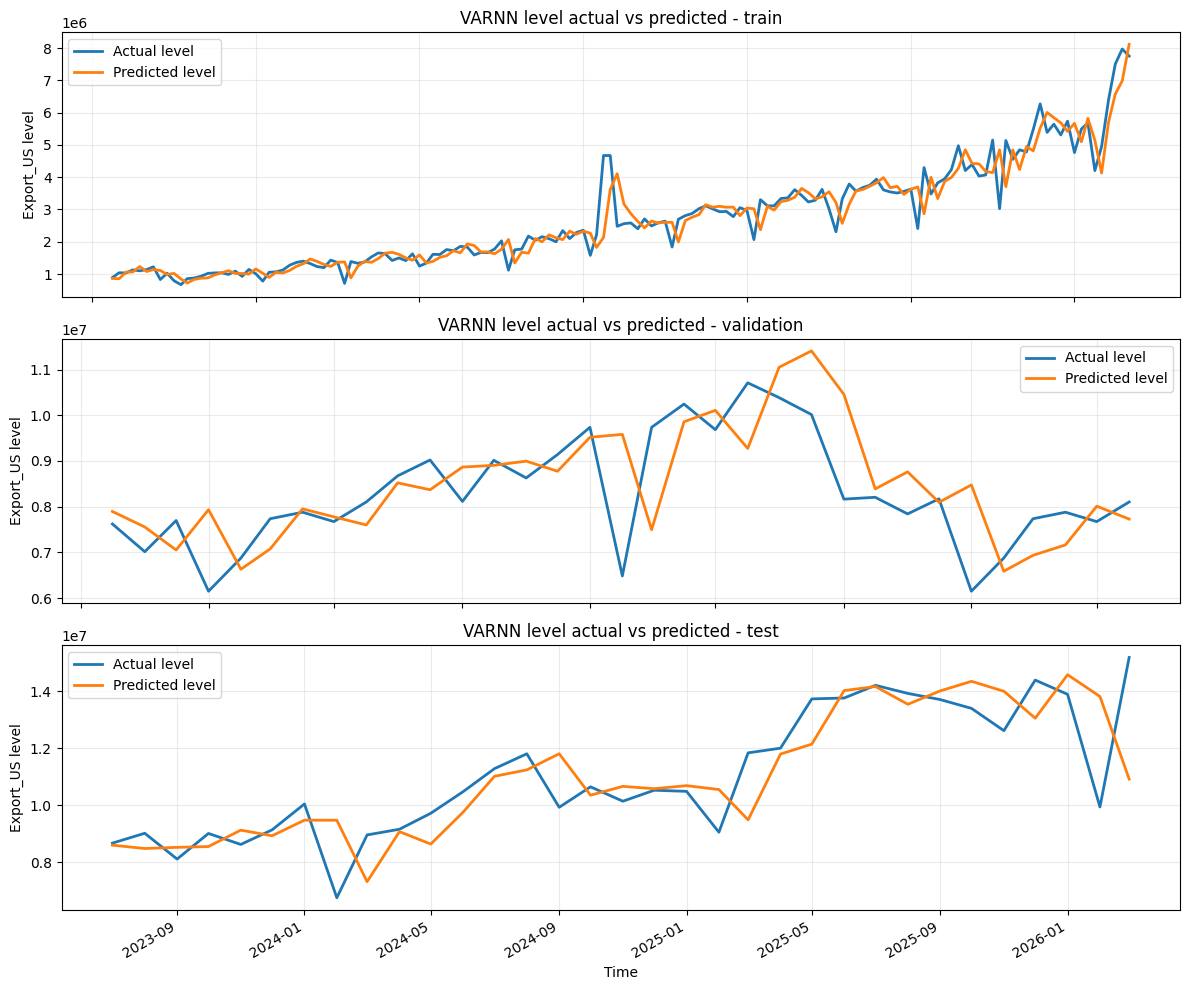

In [78]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
for ax, split in zip(axes, ["train", "validation", "test"]):
    split_df = forecast_df[forecast_df["split"].eq(split)].sort_values("date")
    ax.plot(split_df["date"], split_df["actual_level"], label="Actual level", linewidth=2)
    ax.plot(split_df["date"], split_df["predicted_level"], label="Predicted level", linewidth=2)
    ax.set_title(f"VARNN level actual vs predicted - {split}")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{data_config.target} level")
    ax.grid(True, alpha=0.25)
    ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT_DIR / "varnn_level_actual_vs_predicted_train_val_test.png", dpi=160)
plt.show()


In [79]:
stationarity_screen


,Variable,ADF level p,KPSS level p,ADF diff1 p,KPSS diff1 p,Transform used,Decision basis
0,Export_US,0.985539,0.01,2.799681e-08,0.100000,diff1,train_only
1,PCE,0.932836,0.01,1.343426e-10,0.100000,diff1,train_only
2,US_Retail,0.977512,0.01,2.569037e-06,0.100000,diff1,train_only
3,US_Sentiment,0.362768,0.01,1.153303e-18,0.100000,diff1,train_only
4,USD_VND,0.001213,0.01,6.408139e-23,0.027608,diff1,train_only
5,Import_CN,0.321915,0.01,5.507393e-08,0.100000,diff1,train_only
